In [1]:
# ============================================================
# Block 1: Imports, GPU Check & Setup
# ============================================================

# Install scikit-learn metrics if needed
!pip install -q scikit-learn

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM, Bidirectional,
                                      GRU, Dense, Dropout, Input)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve, auc,
                              precision_recall_curve, average_precision_score,
                              matthews_corrcoef, cohen_kappa_score, brier_score_loss)
from collections import Counter
from wordcloud import WordCloud
import time
import warnings
import os

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Create directory to save images & models
os.makedirs('/content/project_outputs', exist_ok=True)
os.makedirs('/content/project_outputs/images', exist_ok=True)
os.makedirs('/content/project_outputs/models', exist_ok=True)

# GPU Check
print("=" * 60)
print("SYSTEM INFORMATION")
print("=" * 60)
print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")
print(f"NumPy Version: {np.__version__}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"\n✅ GPU Available: {gpus[0].name}")
    print(f"   GPU Device: {tf.test.gpu_device_name()}")
else:
    print("\n⚠️ No GPU detected. Training will be slower.")

print("=" * 60)

# Hyperparameters
VOCAB_SIZE = 10000        # Top 10,000 most frequent words
MAX_LEN = 100             # Pad/truncate sequences to 100 words
EMBEDDING_DIM = 128       # Embedding dimension
BATCH_SIZE = 64
EPOCHS = 10

print("\nHyperparameters:")
print(f"  Vocabulary Size : {VOCAB_SIZE}")
print(f"  Max Sequence Len: {MAX_LEN}")
print(f"  Embedding Dim   : {EMBEDDING_DIM}")
print(f"  Batch Size      : {BATCH_SIZE}")
print(f"  Epochs          : {EPOCHS}")
print("=" * 60)

SYSTEM INFORMATION
TensorFlow Version: 2.20.0
Keras Version: 3.13.2
NumPy Version: 2.1.3

✅ GPU Available: /physical_device:GPU:0
   GPU Device: /device:GPU:0

Hyperparameters:
  Vocabulary Size : 10000
  Max Sequence Len: 100
  Embedding Dim   : 128
  Batch Size      : 64
  Epochs          : 10


In [2]:
# ============================================================
# Block 2: Load IMDb Dataset & Exploration
# ============================================================

# Load the IMDb dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

# Get the word index mapping
word_index = imdb.get_word_index()

# Create reverse mapping: index → word
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = '<PAD>'
reverse_word_index[1] = '<START>'
reverse_word_index[2] = '<UNK>'
reverse_word_index[3] = '<UNUSED>'

# Function to decode a review back to text
def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i, '?') for i in encoded_review])

# ---- Dataset Summary ----
print("=" * 60)
print("IMDb DATASET SUMMARY")
print("=" * 60)
print(f"Training samples   : {len(X_train)}")
print(f"Testing samples    : {len(X_test)}")
print(f"Total samples      : {len(X_train) + len(X_test)}")
print(f"Vocabulary size    : {VOCAB_SIZE}")
print(f"Number of classes  : 2 (0 = Negative, 1 = Positive)")
print()

# Class distribution
train_pos = np.sum(y_train == 1)
train_neg = np.sum(y_train == 0)
test_pos = np.sum(y_test == 1)
test_neg = np.sum(y_test == 0)

print("Training Set Distribution:")
print(f"  Positive reviews : {train_pos} ({train_pos/len(y_train)*100:.1f}%)")
print(f"  Negative reviews : {train_neg} ({train_neg/len(y_train)*100:.1f}%)")
print()
print("Testing Set Distribution:")
print(f"  Positive reviews : {test_pos} ({test_pos/len(y_test)*100:.1f}%)")
print(f"  Negative reviews : {test_neg} ({test_neg/len(y_test)*100:.1f}%)")
print()

# Review length statistics
train_lengths = [len(x) for x in X_train]
test_lengths = [len(x) for x in X_test]

print("Review Length Statistics (before padding):")
print(f"  Training - Min: {min(train_lengths)}, Max: {max(train_lengths)}, "
      f"Mean: {np.mean(train_lengths):.1f}, Median: {np.median(train_lengths):.1f}")
print(f"  Testing  - Min: {min(test_lengths)}, Max: {max(test_lengths)}, "
      f"Mean: {np.mean(test_lengths):.1f}, Median: {np.median(test_lengths):.1f}")
print()

# Display sample reviews
print("=" * 60)
print("SAMPLE REVIEWS")
print("=" * 60)
for i in range(3):
    sentiment = "Positive ✅" if y_train[i] == 1 else "Negative ❌"
    decoded = decode_review(X_train[i])
    print(f"\nReview {i+1} [{sentiment}] (Length: {len(X_train[i])} words):")
    print(f"  {decoded[:300]}...")
    print("-" * 60)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
IMDb DATASET SUMMARY
Training samples   : 25000
Testing samples    : 25000
Total samples      : 50000
Vocabulary size    : 10000
Number of classes  : 2 (0 = Negative, 1 = Positive)

Training Set Distribution:
  Positive reviews : 12500 (50.0%)
  Negative reviews : 12500 (50.0%)

Testing Set Distribution:
  Positive reviews : 12500 (50.0%)
  Negative reviews : 12500 (50.0%)

Review Length Statistics (before padding):
  Training - Min: 11, Max: 2494, Mean: 238.7, Median: 178.0
  Testing  - Min: 7, Max: 2315, Mean: 230.8, Median: 174.0

SAMPLE REVIEWS

Review 1 [Positive ✅] (Length: 218 words):
  <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved th

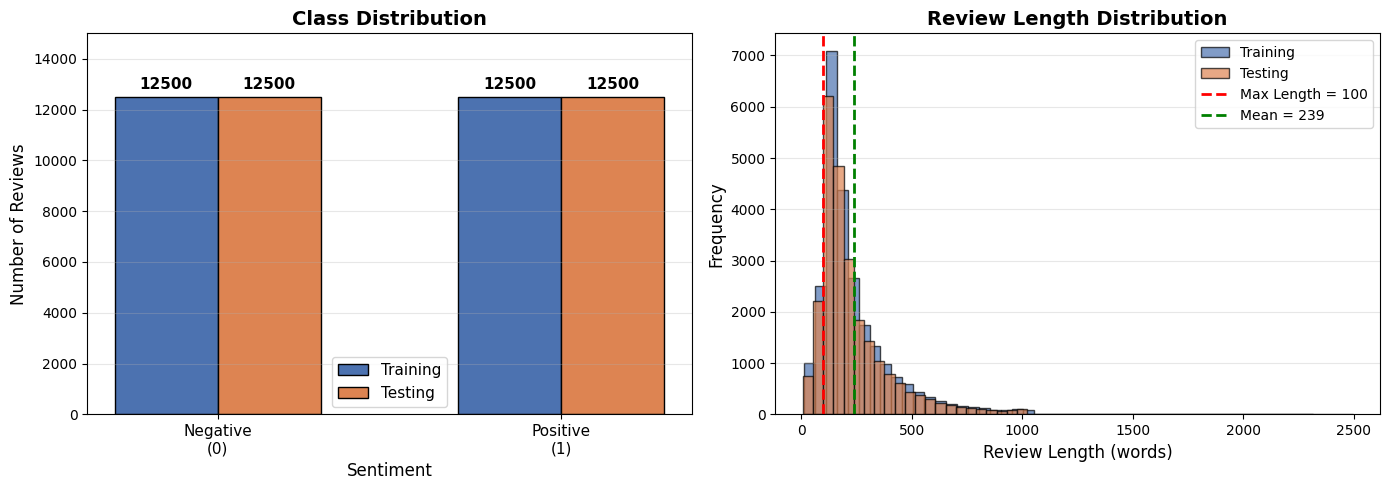

✅ Saved: 01_class_distribution_and_review_length.png


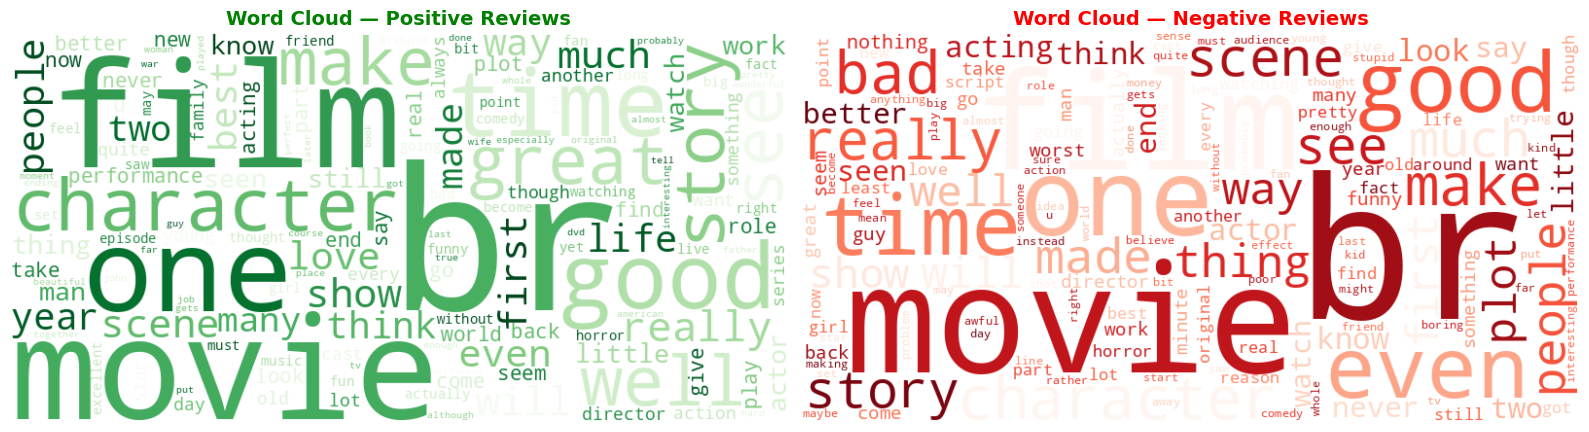

✅ Saved: 02_word_clouds.png


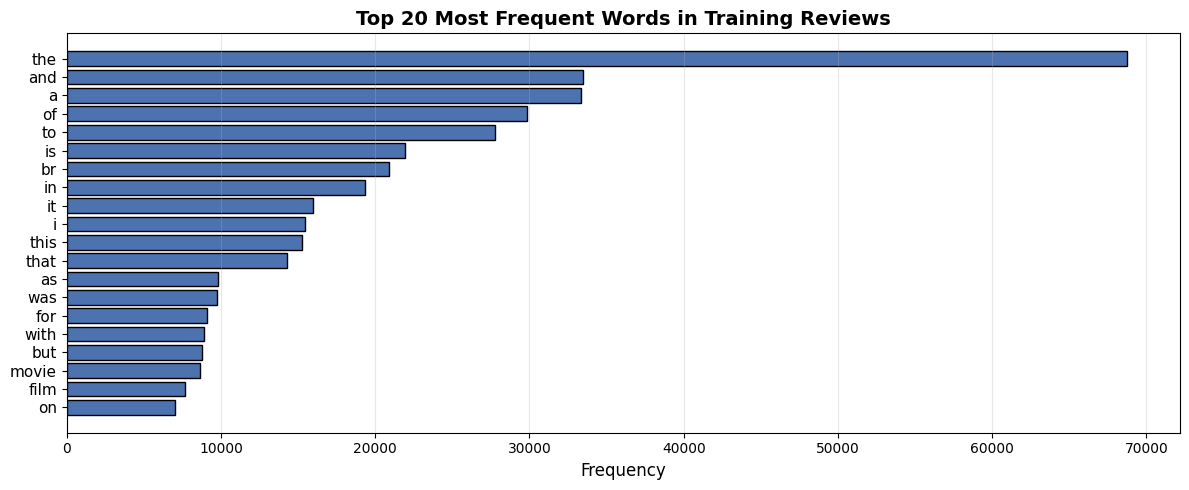

✅ Saved: 03_top20_frequent_words.png


In [3]:
# ============================================================
# Block 3: EDA - Class Distribution, Review Length, Word Clouds
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 1. Class Distribution ---
labels = ['Negative\n(0)', 'Positive\n(1)']
train_counts = [train_neg, train_pos]
test_counts = [test_neg, test_pos]

x = np.arange(len(labels))
width = 0.3

bars1 = axes[0].bar(x - width/2, train_counts, width, label='Training', color='#4C72B0', edgecolor='black')
bars2 = axes[0].bar(x + width/2, test_counts, width, label='Testing', color='#DD8452', edgecolor='black')

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 200,
                 f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold', fontsize=11)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 200,
                 f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold', fontsize=11)

axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment', fontsize=12)
axes[0].set_ylabel('Number of Reviews', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=11)
axes[0].legend(fontsize=11)
axes[0].set_ylim(0, 15000)
axes[0].grid(axis='y', alpha=0.3)

# --- 2. Review Length Distribution ---
axes[1].hist(train_lengths, bins=50, alpha=0.7, color='#4C72B0', edgecolor='black', label='Training')
axes[1].hist(test_lengths, bins=50, alpha=0.7, color='#DD8452', edgecolor='black', label='Testing')
axes[1].axvline(x=MAX_LEN, color='red', linestyle='--', linewidth=2, label=f'Max Length = {MAX_LEN}')
axes[1].axvline(x=np.mean(train_lengths), color='green', linestyle='--', linewidth=2,
                label=f'Mean = {np.mean(train_lengths):.0f}')
axes[1].set_title('Review Length Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Review Length (words)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/project_outputs/images/01_class_distribution_and_review_length.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 01_class_distribution_and_review_length.png")

# --- 3. Word Clouds ---
# Separate positive and negative reviews
pos_reviews = [X_train[i] for i in range(len(X_train)) if y_train[i] == 1]
neg_reviews = [X_train[i] for i in range(len(X_train)) if y_train[i] == 0]

# Decode and join reviews into text
pos_text = ' '.join([decode_review(review) for review in pos_reviews[:3000]])
neg_text = ' '.join([decode_review(review) for review in neg_reviews[:3000]])

# Remove special tokens
for token in ['<START>', '<PAD>', '<UNK>', '<UNUSED>']:
    pos_text = pos_text.replace(token, '')
    neg_text = neg_text.replace(token, '')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive Word Cloud
wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=150, collocations=False).generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Word Cloud — Positive Reviews', fontsize=14, fontweight='bold', color='green')
axes[0].axis('off')

# Negative Word Cloud
wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', max_words=150, collocations=False).generate(neg_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Word Cloud — Negative Reviews', fontsize=14, fontweight='bold', color='red')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('/content/project_outputs/images/02_word_clouds.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 02_word_clouds.png")

# --- 4. Top 20 Most Frequent Words ---
all_words = []
for review in X_train[:5000]:
    all_words.extend(review)

word_counts = Counter(all_words)
# Remove special tokens (indices 0,1,2,3)
for idx in [0, 1, 2, 3]:
    word_counts.pop(idx, None)

top_20 = word_counts.most_common(20)
words = [reverse_word_index.get(idx, '?') for idx, _ in top_20]
counts = [count for _, count in top_20]

plt.figure(figsize=(12, 5))
plt.barh(range(len(words)), counts, color='#4C72B0', edgecolor='black')
plt.yticks(range(len(words)), words, fontsize=11)
plt.xlabel('Frequency', fontsize=12)
plt.title('Top 20 Most Frequent Words in Training Reviews', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/project_outputs/images/03_top20_frequent_words.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 03_top20_frequent_words.png")

In [4]:
# ============================================================
# Block 4: Data Preprocessing - Padding Sequences
# ============================================================

# Pad sequences to ensure uniform length
X_train_pad = pad_sequences(X_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test, maxlen=MAX_LEN, padding='post', truncating='post')

print("=" * 60)
print("DATA PREPROCESSING - PADDING")
print("=" * 60)
print(f"\nBefore Padding:")
print(f"  X_train shapes vary: e.g., {len(X_train[0])}, {len(X_train[1])}, {len(X_train[2])} words")
print(f"\nAfter Padding (maxlen={MAX_LEN}, padding='post', truncating='post'):")
print(f"  X_train_pad shape : {X_train_pad.shape}")
print(f"  X_test_pad shape  : {X_test_pad.shape}")
print(f"  y_train shape     : {y_train.shape}")
print(f"  y_test shape      : {y_test.shape}")

# Show example of padded sequence
print(f"\nSample padded sequence (first review, first 20 tokens):")
print(f"  {X_train_pad[0][:20]}")
print(f"  ... last 20 tokens: {X_train_pad[0][-20:]}")

# Show how many reviews are truncated vs padded
truncated = sum(1 for l in train_lengths if l > MAX_LEN)
padded = sum(1 for l in train_lengths if l < MAX_LEN)
exact = sum(1 for l in train_lengths if l == MAX_LEN)

print(f"\nTraining set stats with MAX_LEN={MAX_LEN}:")
print(f"  Reviews truncated  : {truncated} ({truncated/len(train_lengths)*100:.1f}%)")
print(f"  Reviews padded     : {padded} ({padded/len(train_lengths)*100:.1f}%)")
print(f"  Reviews exact      : {exact} ({exact/len(train_lengths)*100:.1f}%)")

# Create validation split from training data
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_pad, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"\nFinal Data Splits:")
print(f"  Training   : {X_train_final.shape[0]} samples")
print(f"  Validation : {X_val.shape[0]} samples")
print(f"  Testing    : {X_test_pad.shape[0]} samples")
print("=" * 60)

DATA PREPROCESSING - PADDING

Before Padding:
  X_train shapes vary: e.g., 218, 189, 141 words

After Padding (maxlen=100, padding='post', truncating='post'):
  X_train_pad shape : (25000, 100)
  X_test_pad shape  : (25000, 100)
  y_train shape     : (25000,)
  y_test shape      : (25000,)

Sample padded sequence (first review, first 20 tokens):
  [   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25]
  ... last 20 tokens: [ 515   17   12   16  626   18    2    5   62  386   12    8  316    8
  106    5    4 2223 5244   16]

Training set stats with MAX_LEN=100:
  Reviews truncated  : 22178 (88.7%)
  Reviews padded     : 2773 (11.1%)
  Reviews exact      : 49 (0.2%)

Final Data Splits:
  Training   : 20000 samples
  Validation : 5000 samples
  Testing    : 25000 samples


In [7]:
# ============================================================
# Block 5: Build & Train Simple RNN Model (Fixed)
# ============================================================

# Dictionary to store all results
results = {}
histories = {}
models = {}

# --- Simple RNN Model ---
print("=" * 60)
print("MODEL 1: SIMPLE RNN")
print("=" * 60)

model_rnn = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    SimpleRNN(128, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
], name='Simple_RNN')

model_rnn.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

model_rnn.summary()

# Count parameters
rnn_params = model_rnn.count_params()
print(f"\nTotal Parameters: {rnn_params:,}")

# Train
print("\n🚀 Training Simple RNN...")
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

start_time = time.time()
history_rnn = model_rnn.fit(
    X_train_final, y_train_final,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)
rnn_train_time = time.time() - start_time
rnn_time_per_epoch = rnn_train_time / len(history_rnn.history['loss'])

print(f"\n✅ Training Complete!")
print(f"   Total Time  : {rnn_train_time:.2f}s")
print(f"   Time/Epoch  : {rnn_time_per_epoch:.2f}s")
print(f"   Best Val Loss: {min(history_rnn.history['val_loss']):.4f}")
print(f"   Best Val Acc : {max(history_rnn.history['val_accuracy']):.4f}")

# Store results
models['Simple RNN'] = model_rnn
histories['Simple RNN'] = history_rnn
results['Simple RNN'] = {
    'train_time': rnn_train_time,
    'time_per_epoch': rnn_time_per_epoch,
    'params': rnn_params
}

MODEL 1: SIMPLE RNN


Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,025 (5.01 MB)

 Trainable params: 1,313,025 (5.01 MB)

 Non-trainable params: 0 (0.00 B)


Total Parameters: 1,313,025

🚀 Training Simple RNN...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.5076 - loss: 0.7131 - val_accuracy: 0.5304 - val_loss: 0.6923
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5935 - loss: 0.6692 - val_accuracy: 0.5320 - val_loss: 0.7072
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7495 - loss: 0.5064 - val_accuracy: 0.6402 - val_loss: 0.7405
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8637 - loss: 0.3137 - val_accuracy: 0.6688 - val_loss: 0.8470

✅ Training Complete!
   Total Time  : 19.10s
   Time/Epoch  : 4.78s
   Best Val Loss: 0.6923
   Best Val Acc : 0.6688


In [8]:
# ============================================================
# Block 6: Build & Train LSTM Model
# ============================================================

print("=" * 60)
print("MODEL 2: LSTM")
print("=" * 60)

model_lstm = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
], name='LSTM_Model')

model_lstm.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

model_lstm.summary()

lstm_params = model_lstm.count_params()
print(f"\nTotal Parameters: {lstm_params:,}")

# Train
print("\n🚀 Training LSTM...")
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

start_time = time.time()
history_lstm = model_lstm.fit(
    X_train_final, y_train_final,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)
lstm_train_time = time.time() - start_time
lstm_time_per_epoch = lstm_train_time / len(history_lstm.history['loss'])

print(f"\n✅ Training Complete!")
print(f"   Total Time  : {lstm_train_time:.2f}s")
print(f"   Time/Epoch  : {lstm_time_per_epoch:.2f}s")
print(f"   Best Val Loss: {min(history_lstm.history['val_loss']):.4f}")
print(f"   Best Val Acc : {max(history_lstm.history['val_accuracy']):.4f}")

# Store results
models['LSTM'] = model_lstm
histories['LSTM'] = history_lstm
results['LSTM'] = {
    'train_time': lstm_train_time,
    'time_per_epoch': lstm_time_per_epoch,
    'params': lstm_params
}

MODEL 2: LSTM


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,411,713 (5.39 MB)

 Trainable params: 1,411,713 (5.39 MB)

 Non-trainable params: 0 (0.00 B)


Total Parameters: 1,411,713

🚀 Training LSTM...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7002 - loss: 0.5738 - val_accuracy: 0.8066 - val_loss: 0.4549
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8339 - loss: 0.3961 - val_accuracy: 0.8262 - val_loss: 0.4080
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8722 - loss: 0.3357 - val_accuracy: 0.8094 - val_loss: 0.4396
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9021 - loss: 0.2693 - val_accuracy: 0.8180 - val_loss: 0.4642
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9070 - loss: 0.2577 - val_accuracy: 0.8006 - val_loss: 0.5061

✅ Training Complete!
   Total Time  : 27.76s
   Time/Epoch  : 5.55s
   Best Val Loss: 0.4080
   Best Val Acc : 0.8262


In [9]:
# ============================================================
# Block 7: Build & Train Bi-LSTM Model
# ============================================================

print("=" * 60)
print("MODEL 3: BIDIRECTIONAL LSTM (Bi-LSTM)")
print("=" * 60)

model_bilstm = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
], name='BiLSTM_Model')

model_bilstm.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

model_bilstm.summary()

bilstm_params = model_bilstm.count_params()
print(f"\nTotal Parameters: {bilstm_params:,}")

# Train
print("\n🚀 Training Bi-LSTM...")
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

start_time = time.time()
history_bilstm = model_bilstm.fit(
    X_train_final, y_train_final,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)
bilstm_train_time = time.time() - start_time
bilstm_time_per_epoch = bilstm_train_time / len(history_bilstm.history['loss'])

print(f"\n✅ Training Complete!")
print(f"   Total Time  : {bilstm_train_time:.2f}s")
print(f"   Time/Epoch  : {bilstm_time_per_epoch:.2f}s")
print(f"   Best Val Loss: {min(history_bilstm.history['val_loss']):.4f}")
print(f"   Best Val Acc : {max(history_bilstm.history['val_accuracy']):.4f}")

# Store results
models['Bi-LSTM'] = model_bilstm
histories['Bi-LSTM'] = history_bilstm
results['Bi-LSTM'] = {
    'train_time': bilstm_train_time,
    'time_per_epoch': bilstm_time_per_epoch,
    'params': bilstm_params
}

MODEL 3: BIDIRECTIONAL LSTM (Bi-LSTM)


Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,543,425 (5.89 MB)

 Trainable params: 1,543,425 (5.89 MB)

 Non-trainable params: 0 (0.00 B)


Total Parameters: 1,543,425

🚀 Training Bi-LSTM...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.7525 - loss: 0.5026 - val_accuracy: 0.8294 - val_loss: 0.3944
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8719 - loss: 0.3147 - val_accuracy: 0.8166 - val_loss: 0.4146
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9114 - loss: 0.2282 - val_accuracy: 0.8088 - val_loss: 0.5864
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9328 - loss: 0.1791 - val_accuracy: 0.7986 - val_loss: 0.5281

✅ Training Complete!
   Total Time  : 25.34s
   Time/Epoch  : 6.34s
   Best Val Loss: 0.3944
   Best Val Acc : 0.8294


In [10]:
# ============================================================
# Block 8: Build & Train GRU Model
# ============================================================

print("=" * 60)
print("MODEL 4: GRU")
print("=" * 60)

model_gru = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    GRU(128, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
], name='GRU_Model')

model_gru.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

model_gru.summary()

gru_params = model_gru.count_params()
print(f"\nTotal Parameters: {gru_params:,}")

# Train
print("\n🚀 Training GRU...")
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

start_time = time.time()
history_gru = model_gru.fit(
    X_train_final, y_train_final,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)
gru_train_time = time.time() - start_time
gru_time_per_epoch = gru_train_time / len(history_gru.history['loss'])

print(f"\n✅ Training Complete!")
print(f"   Total Time  : {gru_train_time:.2f}s")
print(f"   Time/Epoch  : {gru_time_per_epoch:.2f}s")
print(f"   Best Val Loss: {min(history_gru.history['val_loss']):.4f}")
print(f"   Best Val Acc : {max(history_gru.history['val_accuracy']):.4f}")

# Store results
models['GRU'] = model_gru
histories['GRU'] = history_gru
results['GRU'] = {
    'train_time': gru_train_time,
    'time_per_epoch': gru_time_per_epoch,
    'params': gru_params
}

print("\n" + "=" * 60)
print("ALL 4 MODELS TRAINED SUCCESSFULLY ✅")
print("=" * 60)

MODEL 4: GRU


Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,379,201 (5.26 MB)

 Trainable params: 1,379,201 (5.26 MB)

 Non-trainable params: 0 (0.00 B)


Total Parameters: 1,379,201

🚀 Training GRU...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5512 - loss: 0.6851 - val_accuracy: 0.7076 - val_loss: 0.5813
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8087 - loss: 0.4235 - val_accuracy: 0.8112 - val_loss: 0.4217
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8963 - loss: 0.2632 - val_accuracy: 0.8194 - val_loss: 0.4576
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9373 - loss: 0.1705 - val_accuracy: 0.8028 - val_loss: 0.6060
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9604 - loss: 0.1106 - val_accuracy: 0.8046 - val_loss: 0.6780

✅ Training Complete!
   Total Time  : 18.77s
   Time/Epoch  : 3.75s
   Best Val Loss: 0.4217
   Best Val Acc : 0.8194

ALL 4 MODELS TRAINED SUCCESSFULLY ✅


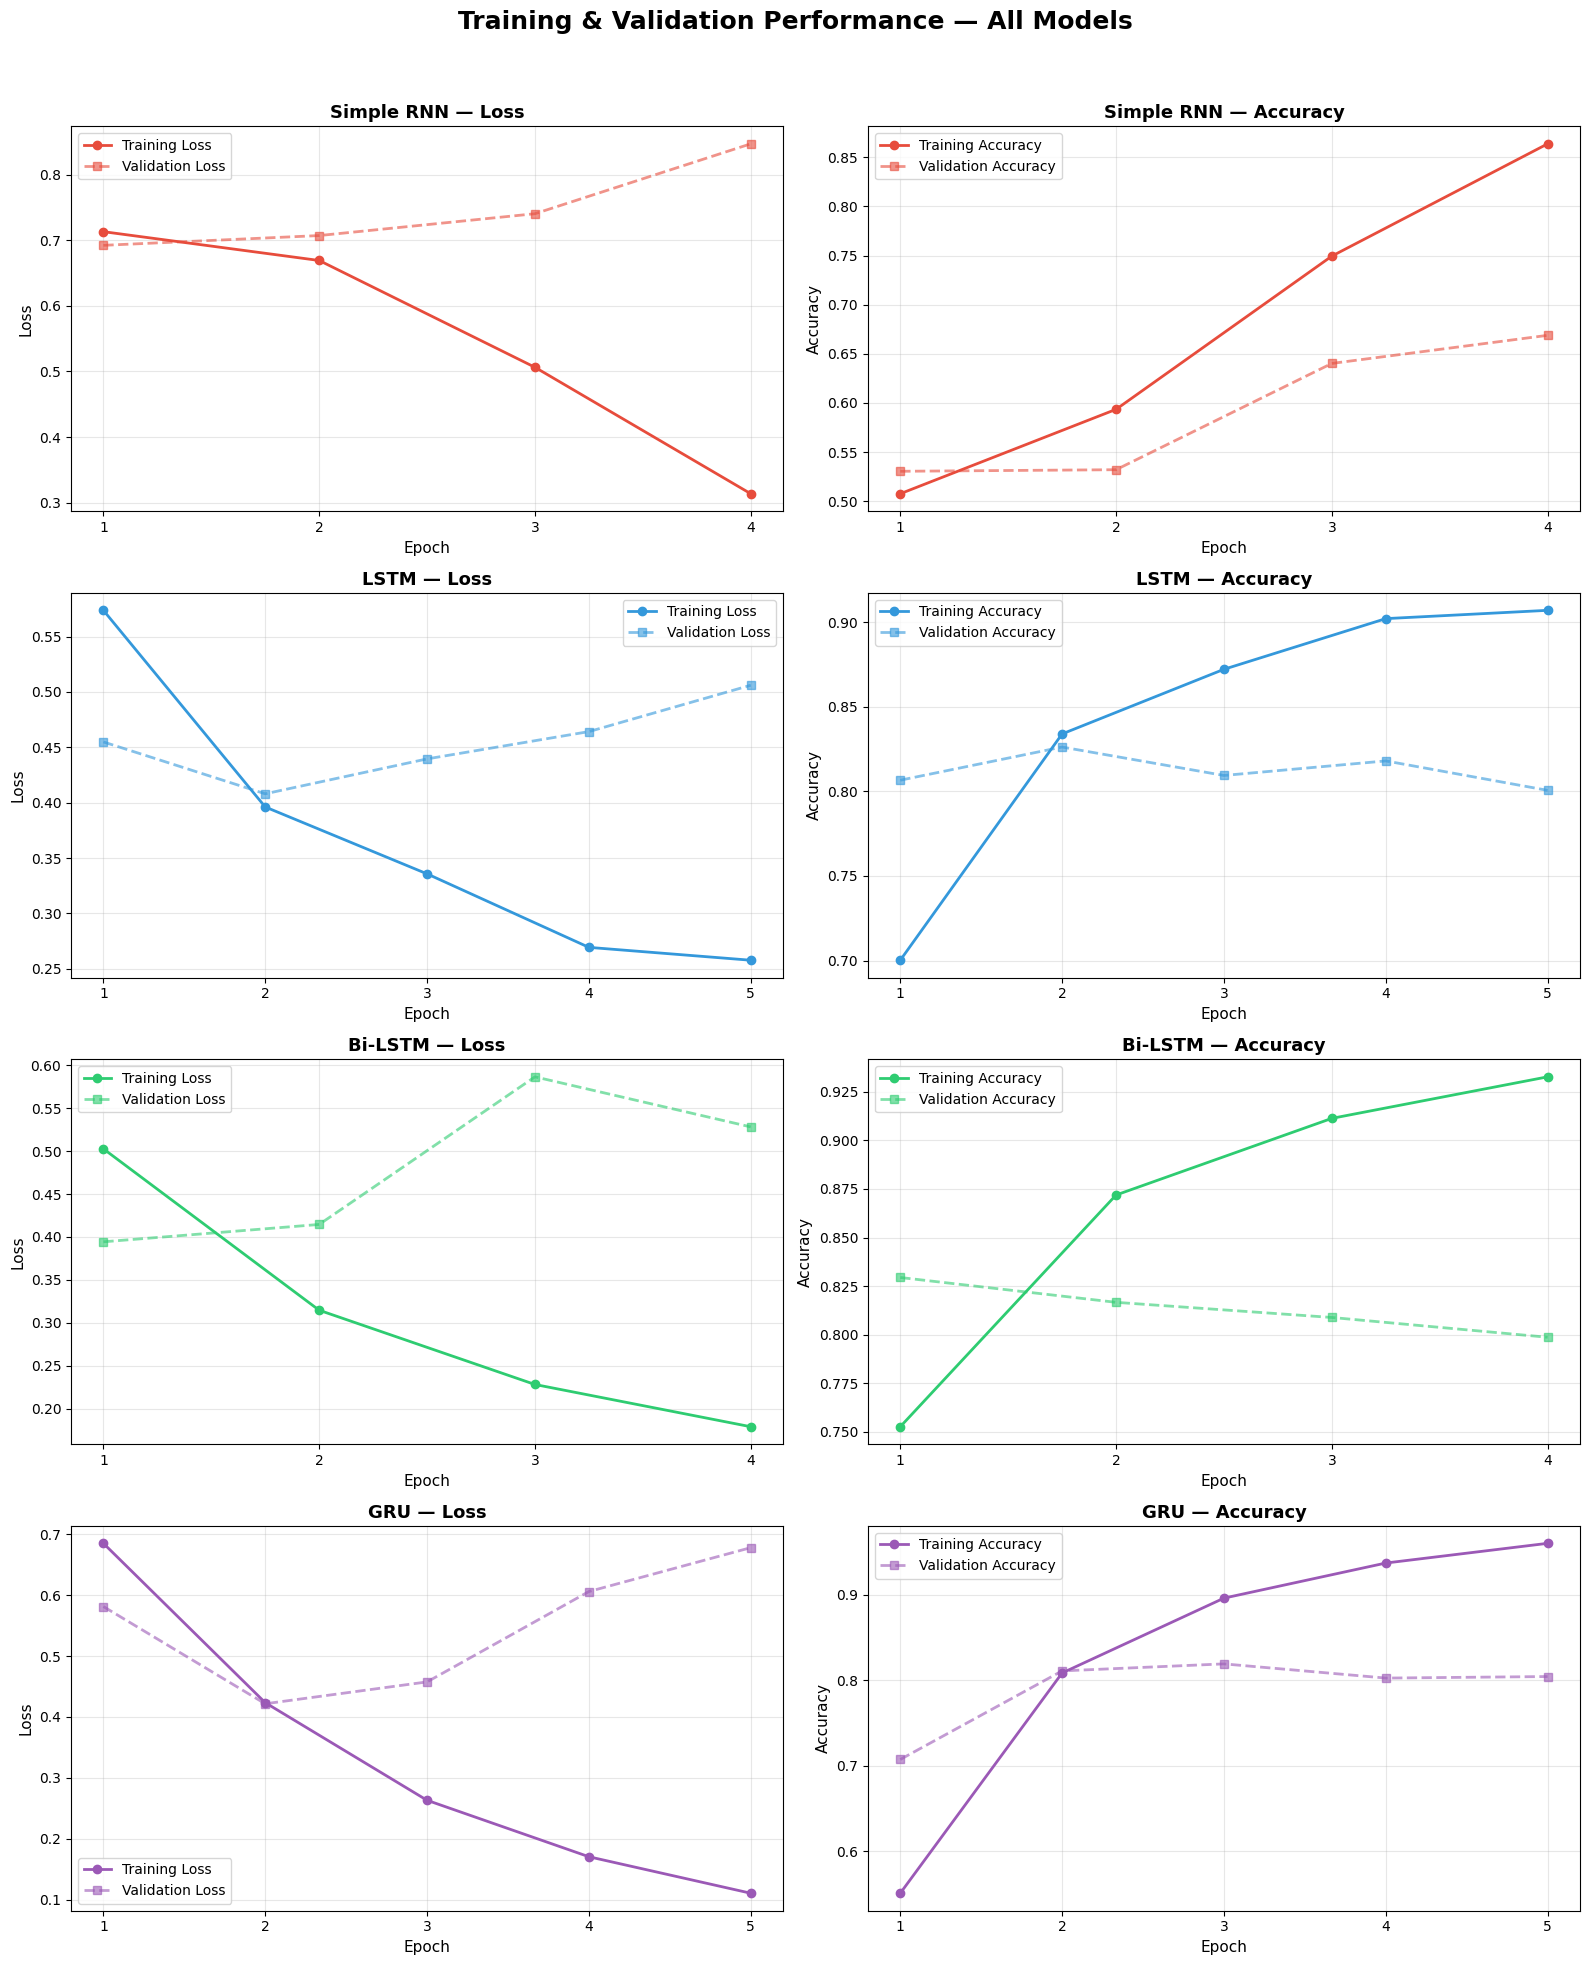

✅ Saved: 04_training_validation_curves.png


In [11]:
# ============================================================
# Block 9: Training & Validation Loss/Accuracy Plots
# ============================================================

model_names = ['Simple RNN', 'LSTM', 'Bi-LSTM', 'GRU']
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
fig.suptitle('Training & Validation Performance — All Models', fontsize=18, fontweight='bold', y=0.98)

for idx, name in enumerate(model_names):
    history = histories[name]
    epochs_range = range(1, len(history.history['loss']) + 1)

    # --- Loss Plot ---
    axes[idx, 0].plot(epochs_range, history.history['loss'], 'o-', color=colors[idx],
                      linewidth=2, markersize=6, label='Training Loss')
    axes[idx, 0].plot(epochs_range, history.history['val_loss'], 's--', color=colors[idx],
                      linewidth=2, markersize=6, alpha=0.6, label='Validation Loss')
    axes[idx, 0].set_title(f'{name} — Loss', fontsize=13, fontweight='bold')
    axes[idx, 0].set_xlabel('Epoch', fontsize=11)
    axes[idx, 0].set_ylabel('Loss', fontsize=11)
    axes[idx, 0].legend(fontsize=10)
    axes[idx, 0].grid(True, alpha=0.3)
    axes[idx, 0].set_xticks(epochs_range)

    # --- Accuracy Plot ---
    axes[idx, 1].plot(epochs_range, history.history['accuracy'], 'o-', color=colors[idx],
                      linewidth=2, markersize=6, label='Training Accuracy')
    axes[idx, 1].plot(epochs_range, history.history['val_accuracy'], 's--', color=colors[idx],
                      linewidth=2, markersize=6, alpha=0.6, label='Validation Accuracy')
    axes[idx, 1].set_title(f'{name} — Accuracy', fontsize=13, fontweight='bold')
    axes[idx, 1].set_xlabel('Epoch', fontsize=11)
    axes[idx, 1].set_ylabel('Accuracy', fontsize=11)
    axes[idx, 1].legend(fontsize=10)
    axes[idx, 1].grid(True, alpha=0.3)
    axes[idx, 1].set_xticks(epochs_range)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('/content/project_outputs/images/04_training_validation_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 04_training_validation_curves.png")

EVALUATION ON TEST SET

📊 Simple RNN:
   Accuracy     : 0.5210
   Precision    : 0.5147
   Recall       : 0.7374
   F1-Score     : 0.6062
   ROC-AUC      : 0.5336
   MCC          : 0.0466
   Cohen's Kappa: 0.0420
   Brier Score  : 0.2502
----------------------------------------

📊 LSTM:
   Accuracy     : 0.8002
   Precision    : 0.8102
   Recall       : 0.7841
   F1-Score     : 0.7969
   ROC-AUC      : 0.8833
   MCC          : 0.6007
   Cohen's Kappa: 0.6004
   Brier Score  : 0.1393
----------------------------------------

📊 Bi-LSTM:
   Accuracy     : 0.8051
   Precision    : 0.8207
   Recall       : 0.7807
   F1-Score     : 0.8002
   ROC-AUC      : 0.8901
   MCC          : 0.6109
   Cohen's Kappa: 0.6102
   Brier Score  : 0.1353
----------------------------------------

📊 GRU:
   Accuracy     : 0.7982
   Precision    : 0.8324
   Recall       : 0.7466
   F1-Score     : 0.7872
   ROC-AUC      : 0.8871
   MCC          : 0.5995
   Cohen's Kappa: 0.5963
   Brier Score  : 0.1422
----------

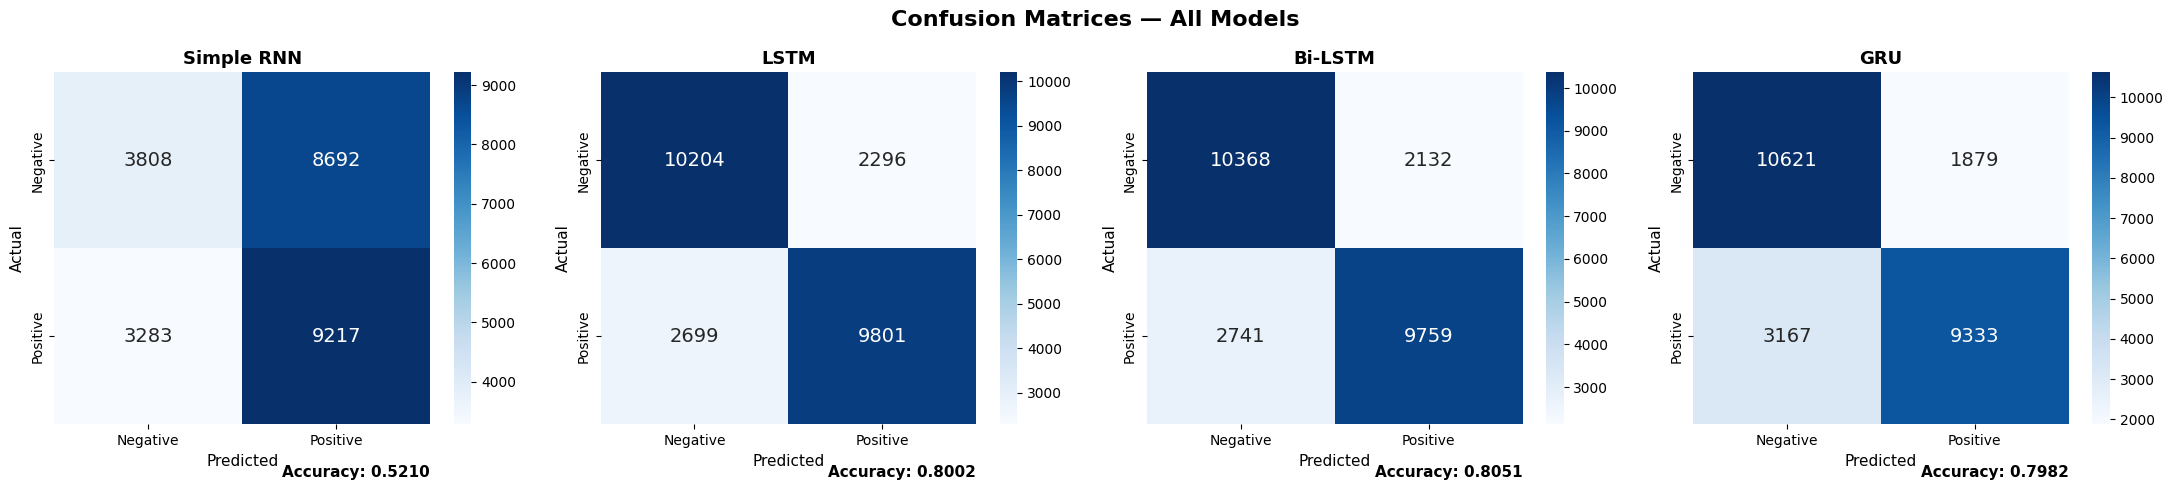

✅ Saved: 05_confusion_matrices.png


In [12]:
# ============================================================
# Block 10: Evaluate All Models on Test Set & Confusion Matrices
# ============================================================

model_names = ['Simple RNN', 'LSTM', 'Bi-LSTM', 'GRU']

print("=" * 60)
print("EVALUATION ON TEST SET")
print("=" * 60)

for name in model_names:
    model = models[name]

    # Get predictions
    y_pred_prob = model.predict(X_test_pad, verbose=0).flatten()
    y_pred = (y_pred_prob >= 0.5).astype(int)

    # Calculate all metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred_prob)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    brier = brier_score_loss(y_test, y_pred_prob)

    # Store metrics
    results[name]['accuracy'] = acc
    results[name]['precision'] = prec
    results[name]['recall'] = rec
    results[name]['f1_score'] = f1
    results[name]['roc_auc'] = roc
    results[name]['mcc'] = mcc
    results[name]['cohen_kappa'] = kappa
    results[name]['brier_score'] = brier
    results[name]['y_pred'] = y_pred
    results[name]['y_pred_prob'] = y_pred_prob

    print(f"\n📊 {name}:")
    print(f"   Accuracy     : {acc:.4f}")
    print(f"   Precision    : {prec:.4f}")
    print(f"   Recall       : {rec:.4f}")
    print(f"   F1-Score     : {f1:.4f}")
    print(f"   ROC-AUC      : {roc:.4f}")
    print(f"   MCC          : {mcc:.4f}")
    print(f"   Cohen's Kappa: {kappa:.4f}")
    print(f"   Brier Score  : {brier:.4f}")
    print("-" * 40)

# --- Confusion Matrices ---
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold')

for idx, name in enumerate(model_names):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                annot_kws={'size': 14})
    axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=11)
    axes[idx].set_ylabel('Actual', fontsize=11)

    # Add accuracy text below
    acc = results[name]['accuracy']
    axes[idx].text(1, -0.15, f'Accuracy: {acc:.4f}',
                   transform=axes[idx].transAxes, ha='right', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/project_outputs/images/05_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 05_confusion_matrices.png")

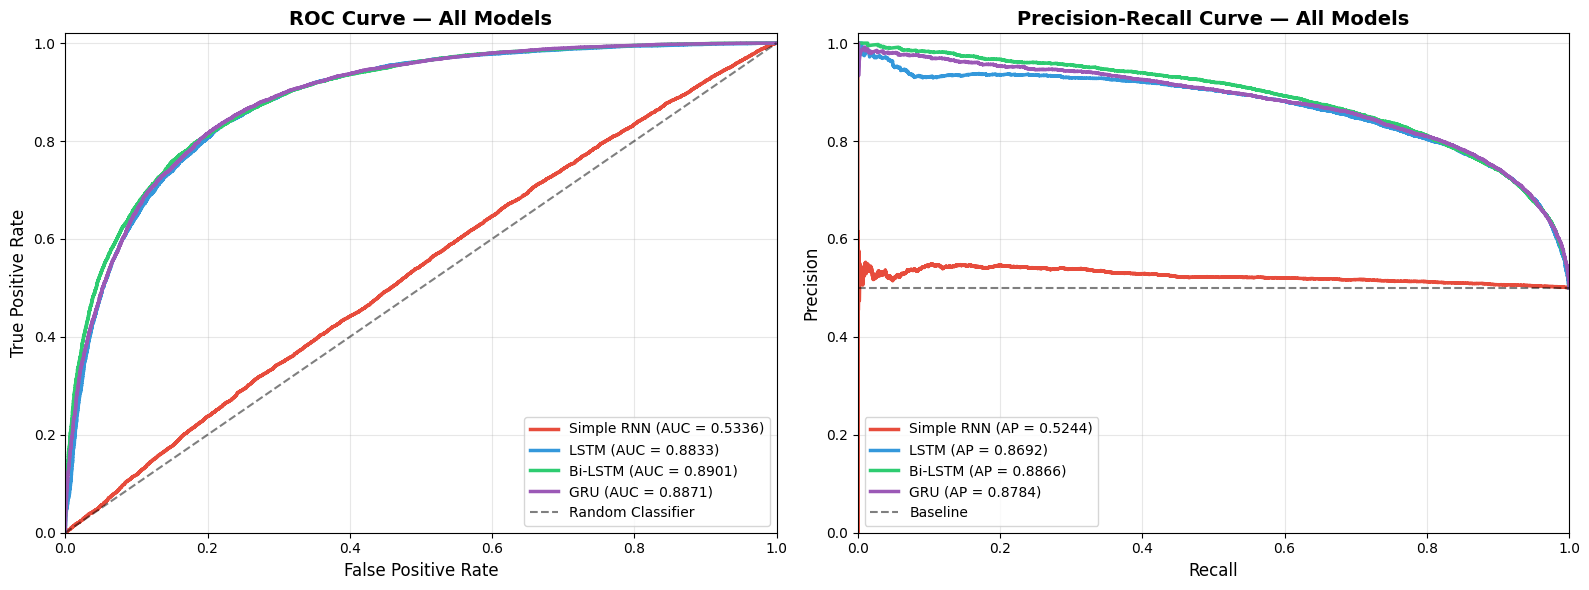

✅ Saved: 06_roc_auc_and_pr_auc_curves.png


In [13]:
# ============================================================
# Block 11: ROC-AUC & PR-AUC Curves (All Models in One Plot)
# ============================================================

model_names = ['Simple RNN', 'LSTM', 'Bi-LSTM', 'GRU']
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- ROC-AUC Curve ---
for idx, name in enumerate(model_names):
    y_prob = results[name]['y_pred_prob']
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=colors[idx], linewidth=2.5,
                 label=f'{name} (AUC = {roc_auc_val:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random Classifier')
axes[0].set_title('ROC Curve — All Models', fontsize=14, fontweight='bold')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].legend(fontsize=10, loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# --- PR-AUC Curve ---
for idx, name in enumerate(model_names):
    y_prob = results[name]['y_pred_prob']
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    pr_auc_val = average_precision_score(y_test, y_prob)
    axes[1].plot(recall_vals, precision_vals, color=colors[idx], linewidth=2.5,
                 label=f'{name} (AP = {pr_auc_val:.4f})')

axes[1].axhline(y=0.5, color='k', linestyle='--', linewidth=1.5, alpha=0.5, label='Baseline')
axes[1].set_title('Precision-Recall Curve — All Models', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].legend(fontsize=10, loc='lower left')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('/content/project_outputs/images/06_roc_auc_and_pr_auc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 06_roc_auc_and_pr_auc_curves.png")

MODEL COMPARISON TABLE
     Model Parameters Train Time (s) Time/Epoch (s) Accuracy Precision Recall F1-Score ROC-AUC    MCC Cohen's Kappa Brier Score
Simple RNN  1,313,025          19.10           4.78   0.5210    0.5147 0.7374   0.6062  0.5336 0.0466        0.0420      0.2502
      LSTM  1,411,713          27.76           5.55   0.8002    0.8102 0.7841   0.7969  0.8833 0.6007        0.6004      0.1393
   Bi-LSTM  1,543,425          25.34           6.34   0.8051    0.8207 0.7807   0.8002  0.8901 0.6109        0.6102      0.1353
       GRU  1,379,201          18.77           3.75   0.7982    0.8324 0.7466   0.7872  0.8871 0.5995        0.5963      0.1422


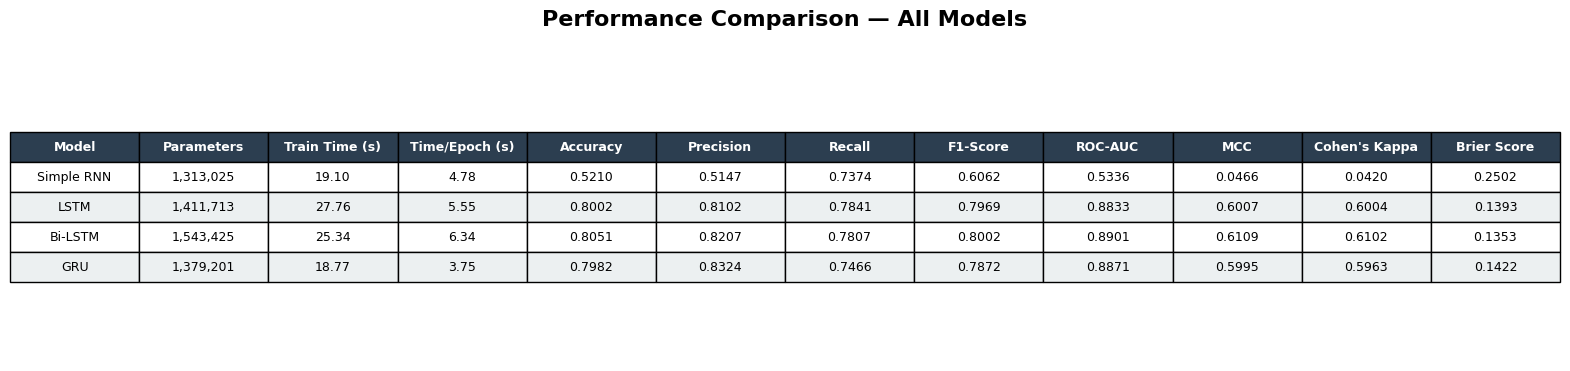

✅ Saved: 07_comparison_table.png


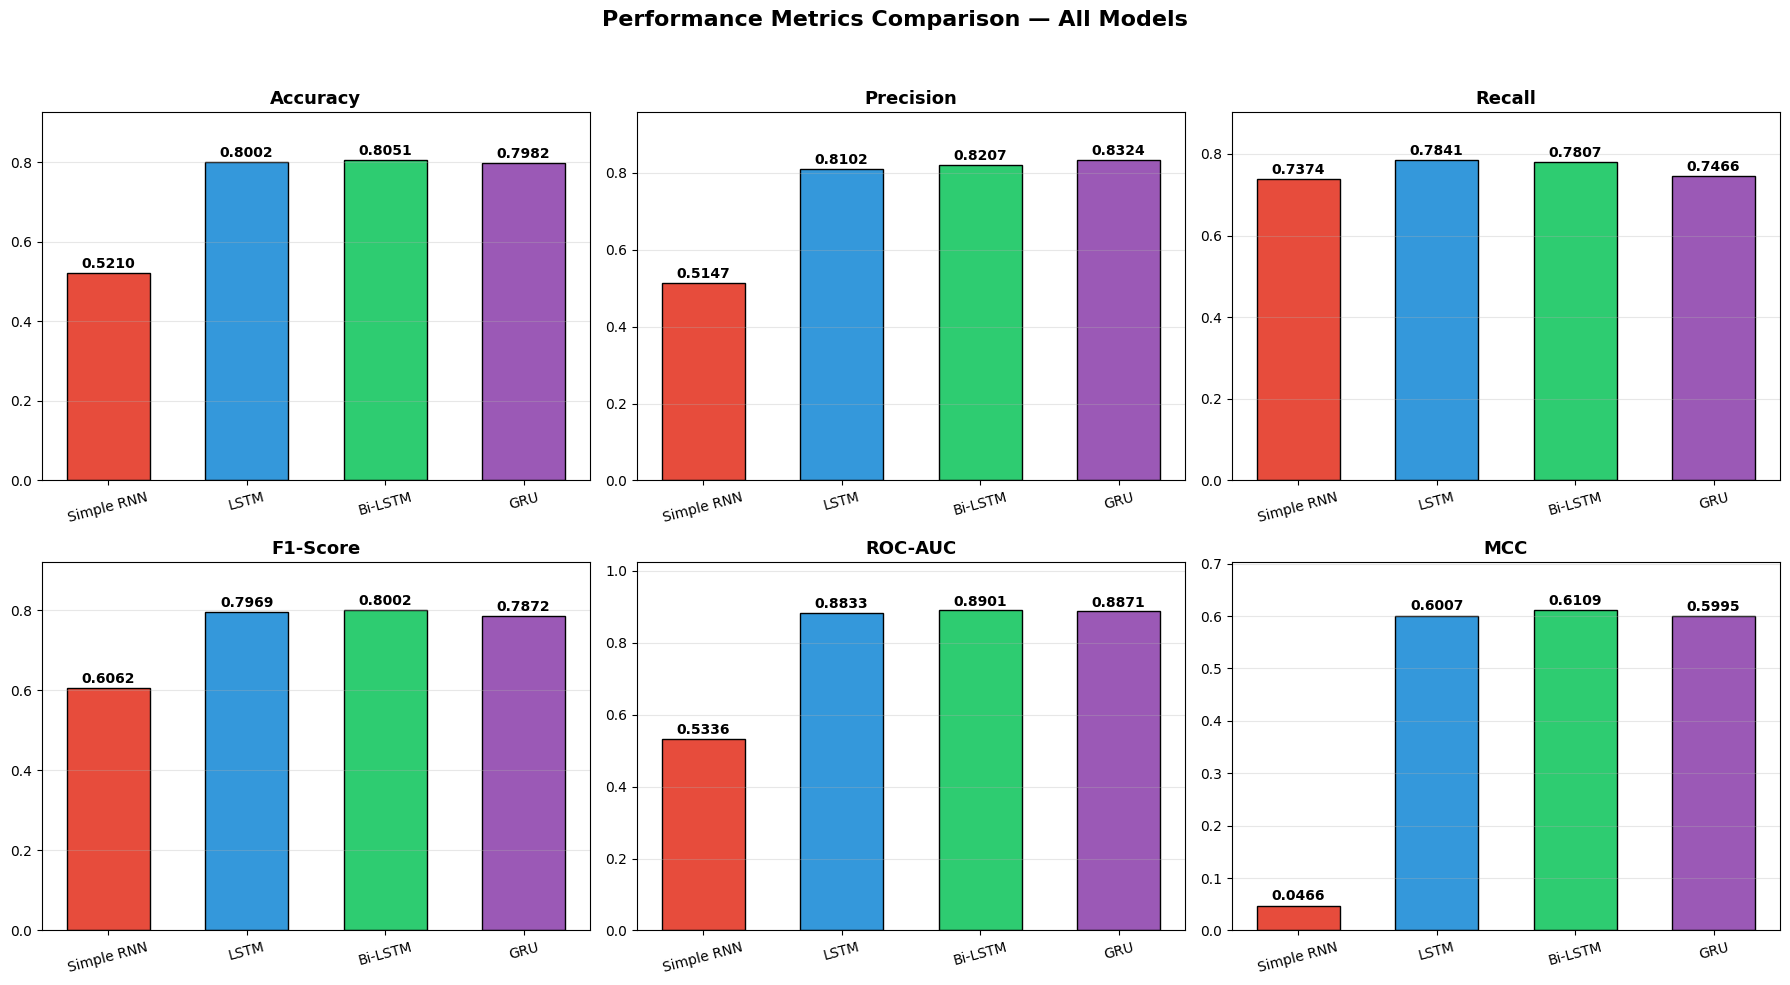

✅ Saved: 08_metrics_bar_charts.png


In [14]:
# ============================================================
# Block 12: Performance Comparison Table & Bar Charts
# ============================================================

import pandas as pd

model_names = ['Simple RNN', 'LSTM', 'Bi-LSTM', 'GRU']

# --- Build Comparison Table ---
table_data = []
for name in model_names:
    r = results[name]
    table_data.append({
        'Model': name,
        'Parameters': f"{r['params']:,}",
        'Train Time (s)': f"{r['train_time']:.2f}",
        'Time/Epoch (s)': f"{r['time_per_epoch']:.2f}",
        'Accuracy': f"{r['accuracy']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall': f"{r['recall']:.4f}",
        'F1-Score': f"{r['f1_score']:.4f}",
        'ROC-AUC': f"{r['roc_auc']:.4f}",
        'MCC': f"{r['mcc']:.4f}",
        "Cohen's Kappa": f"{r['cohen_kappa']:.4f}",
        'Brier Score': f"{r['brier_score']:.4f}"
    })

df_comparison = pd.DataFrame(table_data)
print("=" * 80)
print("MODEL COMPARISON TABLE")
print("=" * 80)
print(df_comparison.to_string(index=False))
print("=" * 80)

# --- Save Table as Image ---
fig, ax = plt.subplots(figsize=(20, 4))
ax.axis('off')
ax.set_title('Performance Comparison — All Models', fontsize=16, fontweight='bold', pad=20)

table = ax.table(
    cellText=df_comparison.values,
    colLabels=df_comparison.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.8)

# Style header
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#ECF0F1')

plt.savefig('/content/project_outputs/images/07_comparison_table.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 07_comparison_table.png")

# --- Bar Charts for Key Metrics ---
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'mcc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'MCC']
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Performance Metrics Comparison — All Models', fontsize=16, fontweight='bold')

for idx, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    row, col = idx // 3, idx % 3
    values = [results[name][metric] for name in model_names]
    bars = axes[row, col].bar(model_names, values, color=colors, edgecolor='black', width=0.6)

    for bar, val in zip(bars, values):
        axes[row, col].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

    axes[row, col].set_title(label, fontsize=13, fontweight='bold')
    axes[row, col].set_ylim(0, max(values) * 1.15)
    axes[row, col].grid(axis='y', alpha=0.3)
    axes[row, col].tick_params(axis='x', rotation=15)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('/content/project_outputs/images/08_metrics_bar_charts.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 08_metrics_bar_charts.png")

In [15]:
# ============================================================
# Block 13: Classification Reports & Save Best Model
# ============================================================

model_names = ['Simple RNN', 'LSTM', 'Bi-LSTM', 'GRU']

print("=" * 60)
print("CLASSIFICATION REPORTS")
print("=" * 60)

for name in model_names:
    y_pred = results[name]['y_pred']
    print(f"\n{'─'*50}")
    print(f"📋 {name}")
    print(f"{'─'*50}")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# --- Identify Best Model ---
best_model_name = max(model_names, key=lambda n: results[n]['roc_auc'])
best_model = models[best_model_name]

print("=" * 60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"   ROC-AUC  : {results[best_model_name]['roc_auc']:.4f}")
print(f"   Accuracy : {results[best_model_name]['accuracy']:.4f}")
print(f"   F1-Score : {results[best_model_name]['f1_score']:.4f}")
print("=" * 60)

# --- Save Best Model ---
best_model.save('/content/project_outputs/models/best_model.keras')
print(f"\n✅ Best model ({best_model_name}) saved to: /content/project_outputs/models/best_model.keras")

# --- Save All Models ---
for name in model_names:
    safe_name = name.lower().replace(' ', '_').replace('-', '_')
    models[name].save(f'/content/project_outputs/models/{safe_name}_model.keras')
    print(f"✅ {name} model saved: {safe_name}_model.keras")

print("\n✅ All models saved successfully!")

CLASSIFICATION REPORTS

──────────────────────────────────────────────────
📋 Simple RNN
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative       0.54      0.30      0.39     12500
    Positive       0.51      0.74      0.61     12500

    accuracy                           0.52     25000
   macro avg       0.53      0.52      0.50     25000
weighted avg       0.53      0.52      0.50     25000


──────────────────────────────────────────────────
📋 LSTM
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative       0.79      0.82      0.80     12500
    Positive       0.81      0.78      0.80     12500

    accuracy                           0.80     25000
   macro avg       0.80      0.80      0.80     25000
weighted avg       0.80      0.80      0.80     25000


──────────────────────────────────────────────────
📋 Bi-LSTM
───────────────────────────────────

SAMPLE PREDICTIONS — Bi-LSTM (Best Model)

Sample 1:
  Review : "firstly i loved the book more so than the more popular da code and although the film was not well received i liked it and bought the dvd however there..."
  Actual : Negative ❌ | Predicted: Positive ✅ | Prob: 0.6762 | ✘ Wrong
  ─────────────────────────────────────────────────────────────────

Sample 2:
  Review : "it might be a stretch saying this as a die hard fan but the material both written and as performed in it's bad for ya is some of the best..."
  Actual : Positive ✅ | Predicted: Negative ❌ | Prob: 0.4025 | ✘ Wrong
  ─────────────────────────────────────────────────────────────────

Sample 3:
  Review : "neil takes a dramatic turn from his first two films in the company of men your friends and neighbors with this funny and original thriller comedy road movie when betty..."
  Actual : Positive ✅ | Predicted: Positive ✅ | Prob: 0.8595 | ✔️ Correct
  ─────────────────────────────────────────────────────────────────


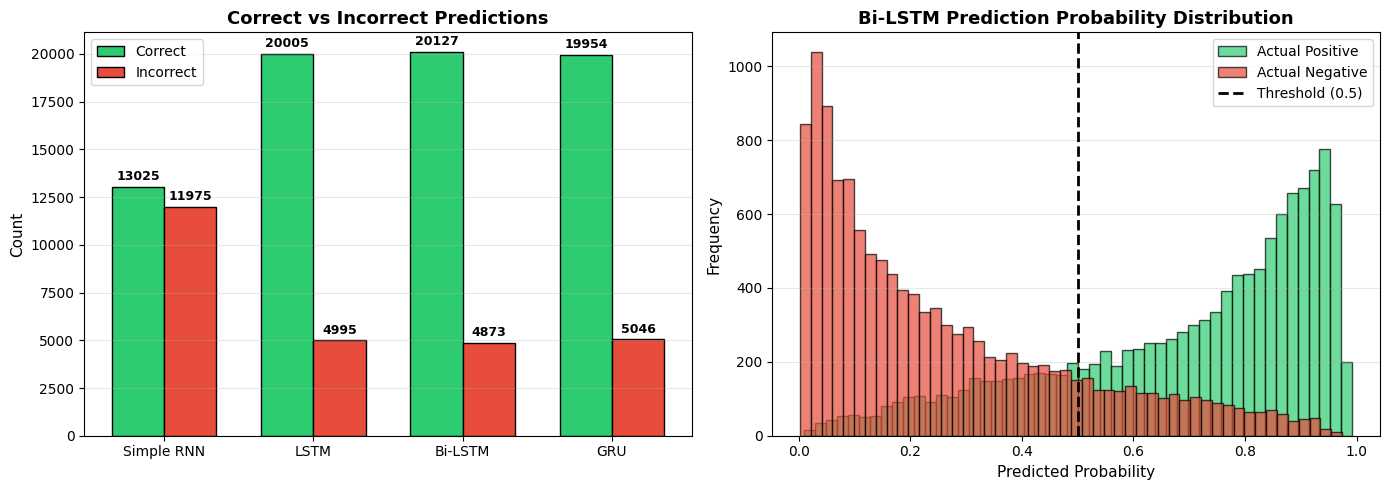

✅ Saved: 09_sample_predictions.png


In [16]:
# ============================================================
# Block 14: Sample Predictions — Show Test Reviews with Results
# ============================================================

# Select 10 random test samples (5 positive, 5 negative)
np.random.seed(42)
pos_indices = np.where(y_test == 1)[0]
neg_indices = np.where(y_test == 0)[0]
sample_pos = np.random.choice(pos_indices, 5, replace=False)
sample_neg = np.random.choice(neg_indices, 5, replace=False)
sample_indices = np.concatenate([sample_pos, sample_neg])
np.random.shuffle(sample_indices)

print("=" * 70)
print("SAMPLE PREDICTIONS — Bi-LSTM (Best Model)")
print("=" * 70)

best_probs = results['Bi-LSTM']['y_pred_prob']
best_preds = results['Bi-LSTM']['y_pred']

for i, idx in enumerate(sample_indices):
    actual = "Positive ✅" if y_test[idx] == 1 else "Negative ❌"
    predicted = "Positive ✅" if best_preds[idx] == 1 else "Negative ❌"
    prob = best_probs[idx]
    correct = "✔️ Correct" if y_test[idx] == best_preds[idx] else "✘ Wrong"

    # Decode the review
    decoded = decode_review(X_test[idx])
    for token in ['<START>', '<PAD>', '<UNK>', '<UNUSED>']:
        decoded = decoded.replace(token, '')
    decoded = ' '.join(decoded.split()[:30])  # First 30 words

    print(f"\nSample {i+1}:")
    print(f"  Review : \"{decoded}...\"")
    print(f"  Actual : {actual} | Predicted: {predicted} | Prob: {prob:.4f} | {correct}")
    print(f"  {'─'*65}")

# --- Prediction Confidence Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names_plot = ['Simple RNN', 'LSTM', 'Bi-LSTM', 'GRU']
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

# Correct vs Incorrect predictions per model
correct_counts = []
incorrect_counts = []
for name in model_names_plot:
    y_pred = results[name]['y_pred']
    correct_counts.append(np.sum(y_pred == y_test))
    incorrect_counts.append(np.sum(y_pred != y_test))

x = np.arange(len(model_names_plot))
width = 0.35

bars1 = axes[0].bar(x - width/2, correct_counts, width, label='Correct', color='#2ECC71', edgecolor='black')
bars2 = axes[0].bar(x + width/2, incorrect_counts, width, label='Incorrect', color='#E74C3C', edgecolor='black')

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 200,
                 f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 200,
                 f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold', fontsize=9)

axes[0].set_title('Correct vs Incorrect Predictions', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names_plot, fontsize=10)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Prediction probability distribution for best model
axes[1].hist(best_probs[y_test == 1], bins=50, alpha=0.7, color='#2ECC71',
             edgecolor='black', label='Actual Positive')
axes[1].hist(best_probs[y_test == 0], bins=50, alpha=0.7, color='#E74C3C',
             edgecolor='black', label='Actual Negative')
axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
axes[1].set_title('Bi-LSTM Prediction Probability Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Probability', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/project_outputs/images/09_sample_predictions.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 09_sample_predictions.png")

In [17]:
# ============================================================
# Block 15: Zip All Outputs & Download from Colab
# ============================================================

import shutil
from google.colab import files

# --- List all saved files ---
print("=" * 60)
print("PROJECT OUTPUTS SUMMARY")
print("=" * 60)

print("\n📁 Images:")
for f in sorted(os.listdir('/content/project_outputs/images')):
    size = os.path.getsize(f'/content/project_outputs/images/{f}') / 1024
    print(f"   📷 {f} ({size:.1f} KB)")

print("\n📁 Models:")
for f in sorted(os.listdir('/content/project_outputs/models')):
    size = os.path.getsize(f'/content/project_outputs/models/{f}') / (1024*1024)
    print(f"   🧠 {f} ({size:.1f} MB)")

# --- Create ZIP ---
zip_path = '/content/sentiment_analysis_project_outputs'
shutil.make_archive(zip_path, 'zip', '/content/project_outputs')

zip_size = os.path.getsize(zip_path + '.zip') / (1024 * 1024)
print(f"\n✅ ZIP created: sentiment_analysis_project_outputs.zip ({zip_size:.1f} MB)")

# --- Download ---
print("\n📥 Downloading ZIP file...")
files.download(zip_path + '.zip')

print("\n" + "=" * 60)
print("🎉 PROJECT COMPLETE!")
print("=" * 60)
print("""
Files included in ZIP:
─────────────────────
📷 01_class_distribution_and_review_length.png
📷 02_word_clouds.png
📷 03_top20_frequent_words.png
📷 04_training_validation_curves.png
📷 05_confusion_matrices.png
📷 06_roc_auc_and_pr_auc_curves.png
📷 07_comparison_table.png
📷 08_metrics_bar_charts.png
📷 09_sample_predictions.png
🧠 best_model.keras (Bi-LSTM)
🧠 simple_rnn_model.keras
🧠 lstm_model.keras
🧠 bi_lstm_model.keras
🧠 gru_model.keras
""")

PROJECT OUTPUTS SUMMARY

📁 Images:
   📷 01_class_distribution_and_review_length.png (205.6 KB)
   📷 02_word_clouds.png (2311.8 KB)
   📷 03_top20_frequent_words.png (101.4 KB)
   📷 04_training_validation_curves.png (1016.1 KB)
   📷 05_confusion_matrices.png (297.6 KB)
   📷 06_roc_auc_and_pr_auc_curves.png (388.3 KB)
   📷 07_comparison_table.png (185.1 KB)
   📷 08_metrics_bar_charts.png (356.4 KB)
   📷 09_sample_predictions.png (213.8 KB)

📁 Models:
   🧠 best_model.keras (17.7 MB)
   🧠 bi_lstm_model.keras (17.7 MB)
   🧠 gru_model.keras (15.8 MB)
   🧠 lstm_model.keras (16.2 MB)
   🧠 simple_rnn_model.keras (15.1 MB)

✅ ZIP created: sentiment_analysis_project_outputs.zip (81.1 MB)

📥 Downloading ZIP file...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 PROJECT COMPLETE!

Files included in ZIP:
─────────────────────
📷 01_class_distribution_and_review_length.png
📷 02_word_clouds.png
📷 03_top20_frequent_words.png
📷 04_training_validation_curves.png
📷 05_confusion_matrices.png
📷 06_roc_auc_and_pr_auc_curves.png
📷 07_comparison_table.png
📷 08_metrics_bar_charts.png
📷 09_sample_predictions.png
🧠 best_model.keras (Bi-LSTM)
🧠 simple_rnn_model.keras
🧠 lstm_model.keras
🧠 bi_lstm_model.keras
🧠 gru_model.keras

